In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/credit-scoring-project/data/engineered_features.csv'
)

print(df.shape)

(307511, 132)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [4]:
thresh = len(df) * 0.5

df = df.dropna(
    thresh=thresh,
    axis=1
)

In [5]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [6]:
X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df['TARGET']

In [7]:
imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (246008, 89), Test: (61503, 89)


In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(246008, 89)
(61503, 89)
(246008,)
(61503,)


In [10]:
X_train.to_csv(
    '/content/drive/MyDrive/credit-scoring-project/data/X_train.csv',
    index=False
)

X_test.to_csv(
    '/content/drive/MyDrive/credit-scoring-project/data/X_test.csv',
    index=False
)

y_train.to_csv(
    '/content/drive/MyDrive/credit-scoring-project/data/y_train.csv',
    index=False
)

y_test.to_csv(
    '/content/drive/MyDrive/credit-scoring-project/data/y_test.csv',
    index=False
)

print("Saved successfully")

Saved successfully


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import lightgbm as lgb
import xgboost as xgb

In [12]:
results = {}

In [13]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict_proba(X_test)[:,1]

results['Logistic Regression'] = roc_auc_score(
    y_test,
    lr_pred
)

print(f"LR AUC: {results['Logistic Regression']:.4f}")

LR AUC: 0.6228


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict_proba(X_test)[:,1]

results['XGBoost'] = roc_auc_score(
    y_test,
    xgb_pred
)

print(f"XGB AUC: {results['XGBoost']:.4f}")

XGB AUC: 0.7649


In [15]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

lgb_pred = lgb_model.predict_proba(X_test)[:,1]

results['LightGBM'] = roc_auc_score(
    y_test,
    lgb_pred
)

print(f"LightGBM AUC: {results['LightGBM']:.4f}")

LightGBM AUC: 0.7638


In [16]:
for name, auc in results.items():
    print(f"{name}: {auc:.4f}")

Logistic Regression: 0.6228
XGBoost: 0.7649
LightGBM: 0.7638


In [17]:
import joblib

joblib.dump(
    lgb_model,
    '/content/drive/MyDrive/credit-scoring-project/models/lightgbm_model.pkl'
)

joblib.dump(
    xgb_model,
    '/content/drive/MyDrive/credit-scoring-project/models/xgboost_model.pkl'
)

print("Models saved")

Models saved


In [18]:
import os

os.listdir('/content/drive/MyDrive/credit-scoring-project/models')

['lightgbm_model.pkl',
 'xgboost_model.pkl',
 'X_test.pkl',
 'y_test.pkl',
 'lgb_pred.pkl',
 'X_train.pkl',
 'y_train.pkl']

In [19]:
TRADITIONAL_FEATURES = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

BEHAVIORAL_FEATURES = [
    'avg_days_late',
    'std_days_late',
    'pct_on_time',
    'num_credit_types',
    'approval_rate',
    'num_prev_applications',
    'active_credits'
]

ALL_FEATURES = TRADITIONAL_FEATURES + BEHAVIORAL_FEATURES

In [20]:
ablation_results = {}

In [21]:
for feature_set_name, cols in [
    ('Traditional only', TRADITIONAL_FEATURES),
    ('Behavioral only', BEHAVIORAL_FEATURES),
    ('Traditional + Behavioral', ALL_FEATURES)
]:
    # Filter to only available columns
    available_cols = [c for c in cols if c in X_train.columns]

    m = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        num_leaves=31, class_weight='balanced',
        random_state=42, verbose=-1
    )
    m.fit(X_train[available_cols], y_train)
    pred = m.predict_proba(X_test[available_cols])[:,1]
    auc = roc_auc_score(y_test, pred)
    ablation_results[feature_set_name] = auc
    print(f"{feature_set_name}: AUC = {auc:.4f}")

Traditional only: AUC = 0.7340
Behavioral only: AUC = 0.6297
Traditional + Behavioral: AUC = 0.7444


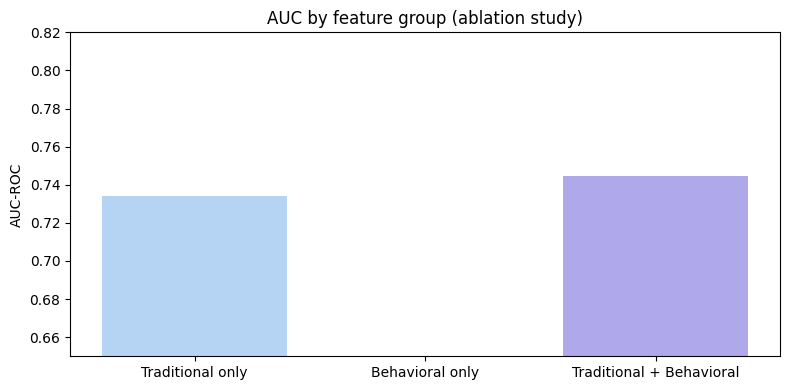

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    ablation_results.keys(),
    ablation_results.values(),
    color=['#B5D4F4', '#9FE1CB', '#AFA9EC']
)

plt.ylim(0.65, 0.82)

plt.ylabel('AUC-ROC')

plt.title('AUC by feature group (ablation study)')

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/credit-scoring-project/reports/ablation.png'
)

plt.show()

In [23]:
print(ablation_results)

{'Traditional only': np.float64(0.7340311502388737), 'Behavioral only': np.float64(0.6296511036593236), 'Traditional + Behavioral': np.float64(0.7443708563503191)}


In [24]:
!pip install shap -q

In [25]:
import shap

In [26]:
explainer = shap.TreeExplainer(lgb_model)

In [27]:
X_sample = X_test.sample(2000, random_state=42)

shap_values = explainer.shap_values(X_sample)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [28]:
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

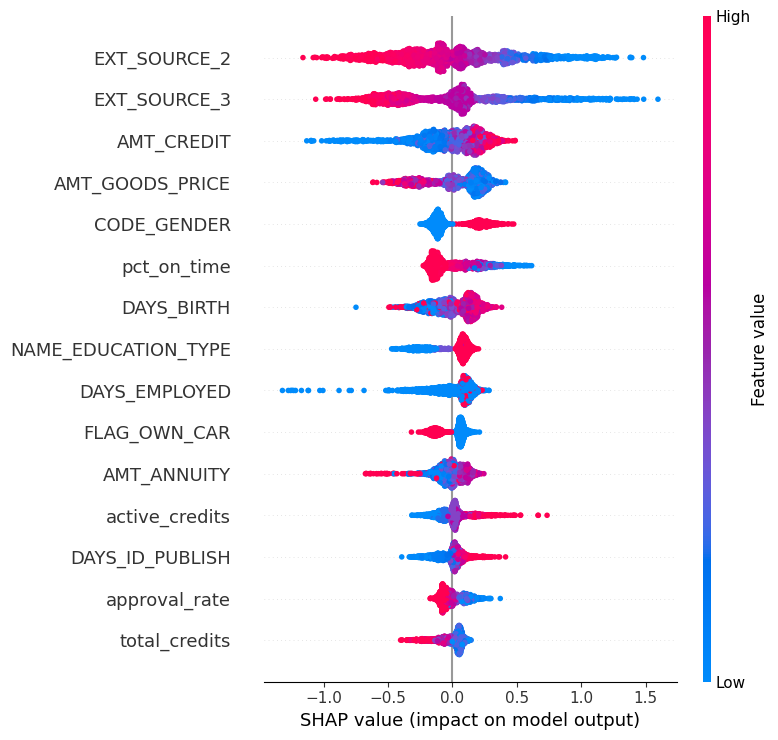

In [29]:
shap.summary_plot(
    sv,
    X_sample,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/credit-scoring-project/reports/shap_summary.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

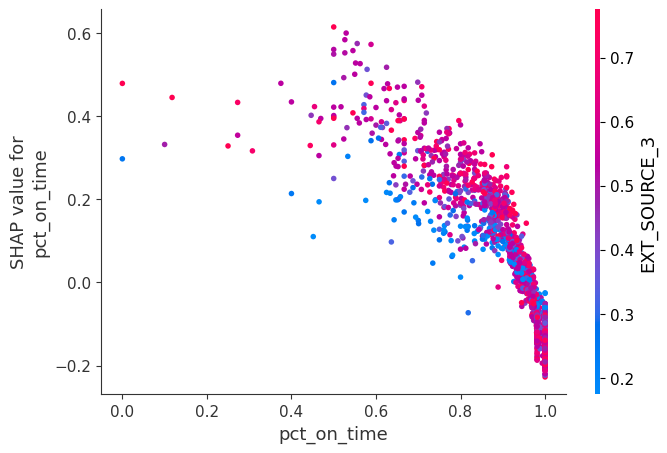

In [30]:
shap.dependence_plot(
    'pct_on_time',
    sv,
    X_sample,
    show=False
)

plt.savefig(
    '/content/drive/MyDrive/credit-scoring-project/reports/shap_dependence.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [31]:
import os

print(
    os.path.exists(
        '/content/drive/MyDrive/credit-scoring-project/reports/shap_summary.png'
    )
)

print(
    os.path.exists(
        '/content/drive/MyDrive/credit-scoring-project/reports/shap_dependence.png'
    )
)

True
True


In [32]:
import joblib

joblib.dump(X_test, '/content/drive/MyDrive/credit-scoring-project/models/X_test.pkl')
joblib.dump(y_test, '/content/drive/MyDrive/credit-scoring-project/models/y_test.pkl')
joblib.dump(lgb_pred, '/content/drive/MyDrive/credit-scoring-project/models/lgb_pred.pkl')

['/content/drive/MyDrive/credit-scoring-project/models/lgb_pred.pkl']

In [33]:
import os

print(os.listdir('/content/drive/MyDrive/credit-scoring-project/models'))

['lightgbm_model.pkl', 'xgboost_model.pkl', 'X_test.pkl', 'y_test.pkl', 'lgb_pred.pkl', 'X_train.pkl', 'y_train.pkl']


In [34]:
import joblib

joblib.dump(X_train, '/content/drive/MyDrive/credit-scoring-project/models/X_train.pkl')
joblib.dump(y_train, '/content/drive/MyDrive/credit-scoring-project/models/y_train.pkl')

print("Saved")

Saved


In [35]:
import joblib

joblib.dump(
    X_train,
    '/content/drive/MyDrive/credit-scoring-project/models/X_train.pkl'
)

joblib.dump(
    y_train,
    '/content/drive/MyDrive/credit-scoring-project/models/y_train.pkl'
)

print("Saved")

Saved


In [36]:
import os

print(os.listdir('/content/drive/MyDrive/credit-scoring-project/models'))

['lightgbm_model.pkl', 'xgboost_model.pkl', 'X_test.pkl', 'y_test.pkl', 'lgb_pred.pkl', 'X_train.pkl', 'y_train.pkl']


In [37]:
print(type(imputer))

<class 'sklearn.impute._base.SimpleImputer'>


In [38]:
import joblib

joblib.dump(
    imputer,
    '/content/drive/MyDrive/credit-scoring-project/models/imputer.pkl'
)

print("Imputer saved")

Imputer saved


In [39]:
import os

print(os.listdir('/content/drive/MyDrive/credit-scoring-project/models'))

['lightgbm_model.pkl', 'xgboost_model.pkl', 'X_test.pkl', 'y_test.pkl', 'lgb_pred.pkl', 'X_train.pkl', 'y_train.pkl', 'imputer.pkl']


In [40]:
import joblib

# Save the trained model (you probably already did this)
joblib.dump(lgb_m, '/content/drive/MyDrive/credit-scoring-project/models/lgbm.pkl')

# NEW — save the median of every column in your training data
median_values = X_train.median()
joblib.dump(median_values, '/content/drive/MyDrive/credit-scoring-project/models/median_values.pkl')

print("Saved. Number of features:", len(median_values))
# Should print: Saved. Number of features: 89

NameError: name 'lgb_m' is not defined